#Phishing_URL_Prediction_Random_Forest_Model

Phishing attacks represent a significant aspect of cybersecurity attacks involves in deceiving users into revealing sensitive information by posing as legitimate entities through fraudulent platforms. They have grown in sophistication and frequency, targeting individuals and organisations and resulting in significant financial and data losses. This project aims to contribute to the fight against such attacks by developing a robust ML model for detecting phishing Websites.

##Project Objective

*  To implement a comprehensive data preparation process with feature selection, dimensionality reduction, and data cleaning to enhance the model performance.
*   To identify and build a predictive model using ML techniques for detecting phishing URLs.

##Business Case

To create a model that accurately predicts phishing URL.
##Goal
To accurately predict phishing URL without falsely predicting phishing URLs which could affect the users.

In [22]:
!pip install -q streamlit

In [23]:
!pip install datacompy

In [24]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import datacompy as dc
import pickle
import os
import plotly.figure_factory as ff
from sklearn import ensemble
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import export_graphviz
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from scipy import stats
import streamlit as st

##Import data, analyze descriptive statistics, drop NULLs

In [25]:
data = pd.read_csv('/content/drive/MyDrive/Collab CSV/URL_Dataset.csv')
data.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [26]:
data.shape

(235795, 56)


##Class Imbalance:

The outcome variable is mildly imbalanced. If the dataset were moderately or severely imbalanced, it would be best to oversample the minorty class or undersample the majority class.

###Some methods include:

- Randomly choosing observations to over/undersample
- SMOTE: synthetically creates new observations based on statistics



In [27]:
#Check for class imbalance
data['label'].value_counts()

,count
label,
1,134850
0,100945



###Exploratory Data Analysis (EDA)

Explore variable distributions and interactions

####     Box plots, histograms, crosstabs

In [28]:
data.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


## Data Cleaning

The dtatset contains of irrelevant data such as text data which have high amount of unique numbers. Some columns ahave high amount of zeros making it less valuable for the model.

In [29]:
#drop of unnecesary/unprocessable features
data = data.drop(columns=['FILENAME', 'URL', 'Domain','URLSimilarityIndex','Title','TLD'])
#reason for the drop
#'FILENAME', 'URL', 'Domain','URLSimilarityIndex','Title','TLD' --> too much unique values.

###Correlation Analysis
Through this we can identify the correlated features. This step is i9mportant due to,

1. Removes redundant, highly correlated features to reduce dimensionality.
2. Detects correlations that distort model coefficients and reduce interpretability.
3. Prevents overfitting and improves generalization.
4. Simplifies the model, reducing training time and cost.
5. Guides transformations or new feature creation.
6. Clarifies relationships between features and the target for better explanation.

In [30]:
# Heatmap
corrs = data.corr()
figure = ff.create_annotated_heatmap(corrs.values,list(corrs.columns),list(corrs.columns), corrs.round(2).values,showscale=True)
figure.show()
# Find all pairs with correlation greater than 0.8 or less than -0.8
threshold = 0.8
high_corr_pairs = []

for i in range(len(corrs.columns)):
    for j in range(i):
        if corrs.iloc[i, j] > threshold or corrs.iloc[i, j] < -threshold:
            high_corr_pairs.append((corrs.columns[i], corrs.columns[j], corrs.iloc[i, j]))

# Print the pairs
for pair in high_corr_pairs:
    print(f"Correlation between {pair[0]} and {pair[1]}: {pair[2]:.2f}")

Correlation between NoOfLettersInURL and URLLength: 0.96
Correlation between NoOfDegitsInURL and URLLength: 0.84
Correlation between NoOfEqualsInURL and NoOfDegitsInURL: 0.81
Correlation between URLTitleMatchScore and DomainTitleMatchScore: 0.96


###Identifying features with high zero vallues

* Features with many zeros may introduce sparsity, impacting model performance and efficiency.
* They can add noise and reduce the model’s ability to learn meaningful patterns.
* High zeros might indicate missing data or binary flags, requiring proper handling or transformation.
* Sparse features can increase dimensionality and computational time, affecting model training.
* Many zeros can skew scaling techniques, making it harder for models to interpret feature distributions.
* Removing such features simplifies the model, improving interpretability and focus on important variables.

In [31]:
# Calculate the percentage of zero values in each column
zero_percentage = (data == 0).mean() * 100

# Filter columns with more than 80% zero values
columns_with_high_zero_percentage = zero_percentage[zero_percentage > 80]

# Get the list of column names and their zero percentages
columns_list = columns_with_high_zero_percentage.index.tolist()
percentages_list = columns_with_high_zero_percentage.values.tolist()

# Display the results
result = pd.DataFrame({
    'Column': columns_list,
    'Percentage of Zero Values': percentages_list})
print(result)

                   Column  Percentage of Zero Values
0              IsDomainIP                  99.729426
1          HasObfuscation                  99.794313
2      NoOfObfuscatedChar                  99.794313
3        ObfuscationRatio                  99.794313
4         NoOfEqualsInURL                  97.709451
5          NoOfQMarkInURL                  97.400284
6      NoOfAmpersandInURL                  99.623826
7         NoOfURLRedirect                  86.656206
8        NoOfSelfRedirect                  95.989313
9               NoOfPopup                  94.312432
10  HasExternalFormSubmit                  95.601264
11       HasPasswordField                  89.773744
12                   Bank                  87.291079
13                 Crypto                  97.652622


##Random Forest Clasifier to identify the feature importance

*   Split training and testing data (80% & 20%)
*   Forest of 100 trees
*   Min 5 samples in a leaf to avoid too many splits
*   Max depth of 4: - Max depth of >4 was not adding to the model and predictive power - Max depth of 4 avoids overfitting


In [32]:
# Dividing dataset into label and feature sets
data['label'] = data['label'].replace({0: 1, 1: 0})
X = data.drop('label', axis = 1) # Features
Y = data['label'] # Labels
print(type(X))
print(type(Y))
print(X.shape)
print(Y.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
(235795, 49)
(235795,)


In [33]:
X_scaled = StandardScaler().fit_transform(X) # scaling

#split dataset into train (80%) and test (20%), shuffle observations
x_train, x_test, y_train, y_test = train_test_split(X_scaled,Y, test_size = 0.3, random_state = 10, shuffle = True)

#build random forest model, limit max depth to avoid overfitting
RF_classifier1 =ensemble.RandomForestClassifier(max_depth=4, random_state = 10, n_estimators = 100, min_samples_leaf=5, criterion='entropy', max_features='sqrt')  # building model
model1=RF_classifier1.fit(x_train,y_train)#training
Y_pred1=RF_classifier1.predict(x_test)# testing
model1

RandomForestClassifier(criterion='entropy', max_depth=4, min_samples_leaf=5,
                       random_state=10)

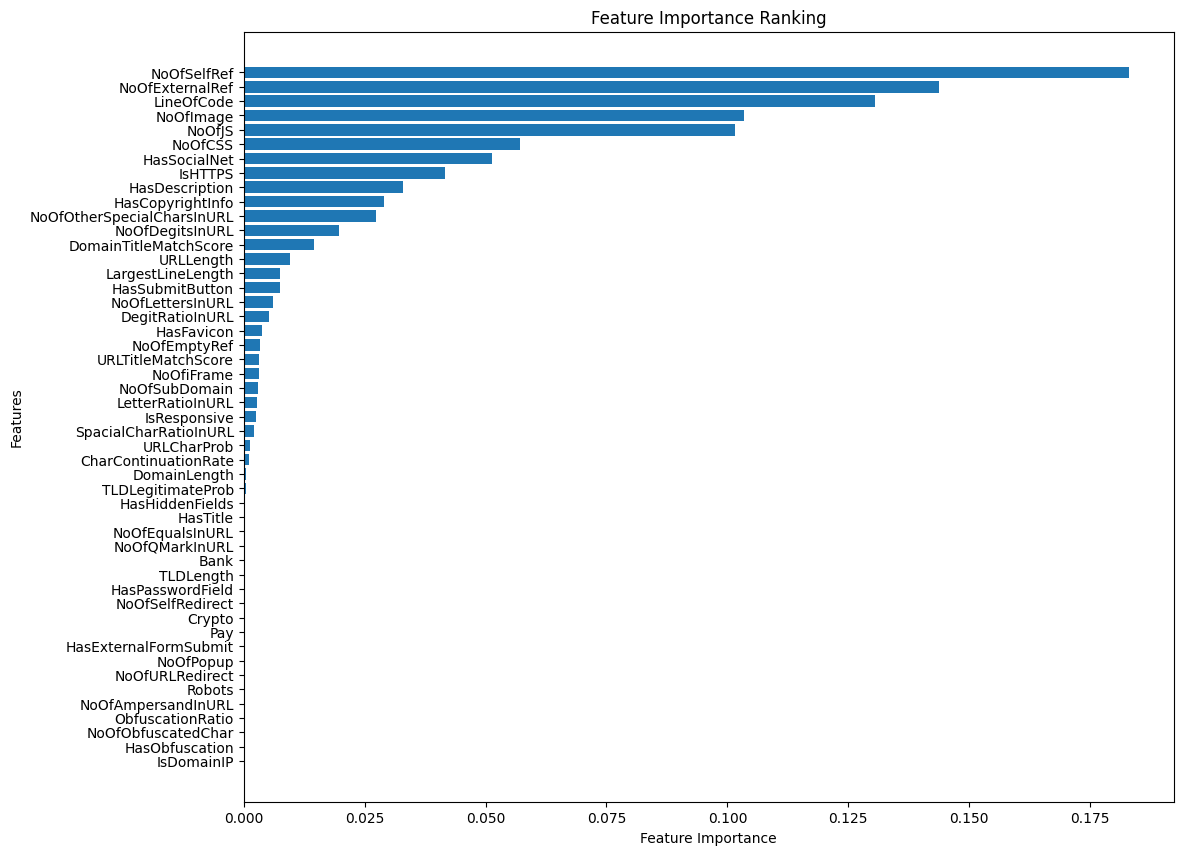

In [34]:
# Set a larger figure size
plt.figure(figsize=(12, 10))  # Adjust the size (width, height) as needed

# Sort the feature importances and create the horizontal bar plot
feature_importance = list(zip(X, RF_classifier1.feature_importances_))
feature_importance.sort(key=lambda x: x[1])

# Create the bar plot
plt.barh([x[0] for x in feature_importance], [x[1] for x in feature_importance])

# Add labels and title for clarity
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance Ranking')

# Show the plot
plt.show()


In [35]:
# Get feature importance and sort
feature_importance = list(zip(X, RF_classifier1.feature_importances_))
feature_importance.sort(key=lambda x: x[1])

# Filter features with importance less than 0.02
low_importance_features = [x[0] for x in feature_importance if x[1] < 0.1]

# Print the list of features with low importance
print("Less significant Features :", low_importance_features)


Less significant Features : ['IsDomainIP', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfAmpersandInURL', 'Robots', 'NoOfURLRedirect', 'NoOfPopup', 'HasExternalFormSubmit', 'Pay', 'Crypto', 'NoOfSelfRedirect', 'HasPasswordField', 'TLDLength', 'Bank', 'NoOfQMarkInURL', 'NoOfEqualsInURL', 'HasTitle', 'HasHiddenFields', 'TLDLegitimateProb', 'DomainLength', 'CharContinuationRate', 'URLCharProb', 'SpacialCharRatioInURL', 'IsResponsive', 'LetterRatioInURL', 'NoOfSubDomain', 'NoOfiFrame', 'URLTitleMatchScore', 'NoOfEmptyRef', 'HasFavicon', 'DegitRatioInURL', 'NoOfLettersInURL', 'HasSubmitButton', 'LargestLineLength', 'URLLength', 'DomainTitleMatchScore', 'NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL', 'HasCopyrightInfo', 'HasDescription', 'IsHTTPS', 'HasSocialNet', 'NoOfCSS']


In [36]:
# List of columns to be dropped due to less importance in RFC and large amount of zero values

# Drop the specified columns from the DataFrame
data = data.drop(columns=low_importance_features)

# Display the resulting DataFrame
print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   LineOfCode       235795 non-null  int64
 1   NoOfImage        235795 non-null  int64
 2   NoOfJS           235795 non-null  int64
 3   NoOfSelfRef      235795 non-null  int64
 4   NoOfExternalRef  235795 non-null  int64
 5   label            235795 non-null  int64
dtypes: int64(6)
memory usage: 10.8 MB
None



#Random Forest Model Tuning:

-Split training and testing data (80% & 20%)

-Min 5 samples in a leaf to avoid too many splits

-Max depth of 4: - Max depth of >4 was not adding to the model and predictive power - Max depth of 4 avoids overfitting
Explanatory/Dependent Variable (Y):

Loan_Approved
Independent Variables:

Gender, Married, TotalApplicantIncome, LoanAmount, Credit_History


In [37]:
# Dividing dataset into label and feature sets
X = data.drop('label', axis = 1) # Features
Y = data['label'] # Labels
print(type(X))
print(type(Y))
print(X.shape)
print(Y.shape)

X_scaled = StandardScaler().fit_transform(X) # scaling

#split dataset into train (80%) and test (20%), shuffle observations
x_train, x_test, y_train, y_test = train_test_split(X_scaled,Y, test_size = 0.3, random_state = 10, shuffle = True)

#build random forest model, limit max depth to avoid overfitting
RF_classifier2 = ensemble.RandomForestClassifier(max_depth=4, random_state = 10, min_samples_leaf=5, criterion='entropy', max_features='sqrt') # building model
no_trees = {'n_estimators': [10,20,50,100,200]}
grid_search1 = GridSearchCV(estimator=RF_classifier2, param_grid=no_trees, scoring='recall', cv=5)
model2=grid_search1.fit(X_scaled, Y)## training, testing , evaluation, ranking.
best_parameters = grid_search1.best_params_
model2
print(best_parameters)
best_result = grid_search1.best_score_
print(best_result)


<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
(235795, 5)
(235795,)
{'n_estimators': 20}
0.9840804398434791


In [21]:
# Random Forest Classifier with best number of tree (method 1)

RF_classifier3 = ensemble.RandomForestClassifier(max_depth=4, random_state = 10, n_estimators = 200, min_samples_leaf=5, criterion='entropy', max_features='sqrt')# building model
model3=RF_classifier3.fit(x_train,y_train) #training
Y_pred3=RF_classifier3.predict(x_test)# testing
model3

RandomForestClassifier(criterion='entropy', max_depth=4, min_samples_leaf=5,
                       n_estimators=200, random_state=10)

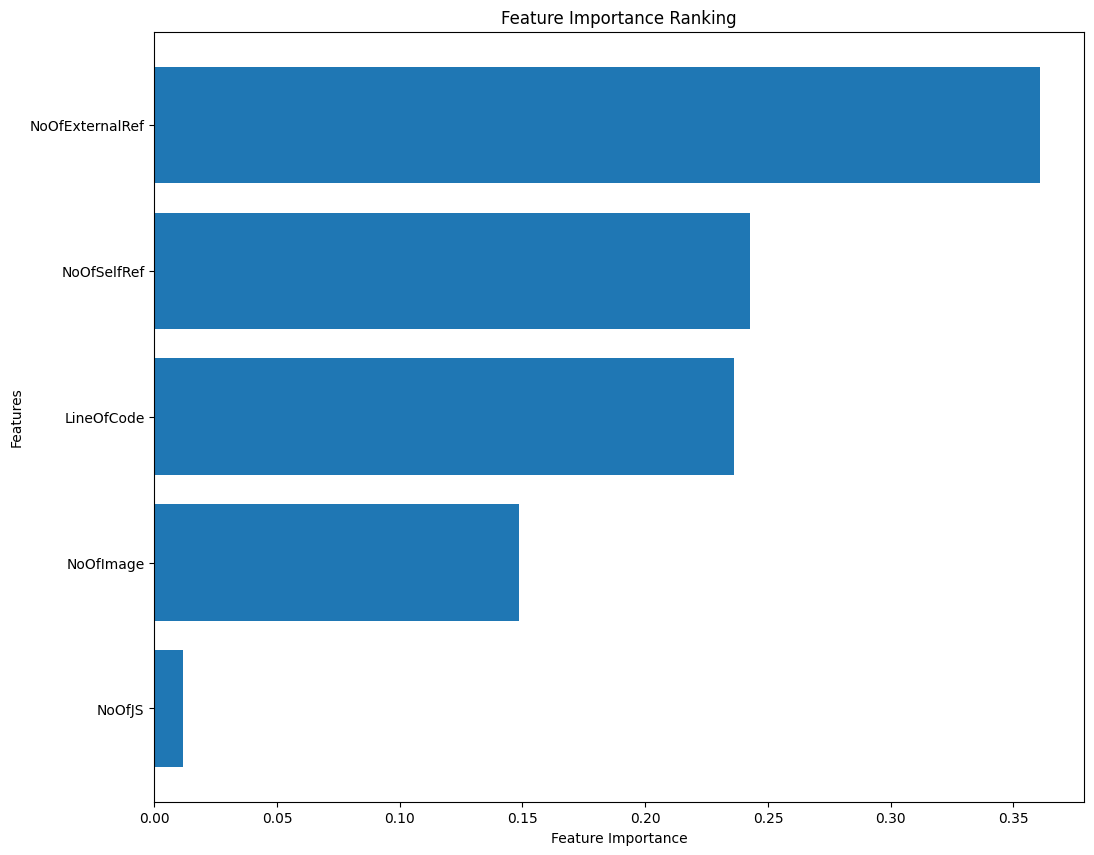

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
# Set a larger figure size
fig=plt.figure(figsize=(12, 10))  # Adjust the size (width, height) as needed

# Sort the feature importances and create the horizontal bar plot
feature_importance = list(zip(X, RF_classifier3.feature_importances_))
feature_importance.sort(key=lambda x: x[1])

# Create the bar plot
plt.barh([x[0] for x in feature_importance], [x[1] for x in feature_importance])

# Add labels and title for clarity
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance Ranking')

# Show the plot
plt.show()

# Save the figure as a PNG image
fig.savefig('FeatureImportance.png')

# download the image
from google.colab import files
files.download('FeatureImportance.png')


In [40]:
# Import necessary libraries
import matplotlib.pyplot as plt
import sklearn as sk

# Ensure feature names are properly retrieved by dropping the 'label' column
feature_names = data.drop('label', axis=1).columns

# Create a figure with a specified size and resolution (32x20 inches, 500 DPI)
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(32, 20), dpi=500)

estimator = model3.estimators_[20]
estimator
model3.estimators_[20].tree_.max_depth

# Plot the decision tree using sklearn's plot_tree function
# Provide feature names from the dataset, set filled=True to color the nodes, and fontsize for readability
sk.tree.plot_tree(estimator,
                  filled=True,
                  fontsize=10,
                  feature_names=feature_names,  # Corrected feature_names
                  class_names=True)

# Save the figure as a PNG image
fig.savefig('DecisionTree.png')

# Display the tree plot inline in Google Colab
plt.show()

# You can download the image directly within Colab using the following command if needed
from google.colab import files
files.download('DecisionTree.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
#Predicted Y (outcome) values for test and training observations
pred_train = model3.predict(x_train)
pred_test = model3.predict(x_test)

#Accuracy
accuracy_train = accuracy_score(y_train,pred_train)
accuracy_test = accuracy_score(y_test,pred_test)


#Precision
precision_train = sk.metrics.precision_score(y_train,pred_train)
precision_test = sk.metrics.precision_score(y_test,pred_test)

#Recall
recall_train = sk.metrics.recall_score(y_train,pred_train)
recall_test = sk.metrics.recall_score(y_test,pred_test)

#F1
f1_train = (2 * precision_train * recall_train) / (precision_train + recall_train)
f1_test = (2 * precision_test * recall_test) / (precision_test + recall_test)


print('Accuracy Train:',accuracy_train,'Accuracy Test:',accuracy_test)
print('Precision Train:',precision_train,'Precision Test:',precision_test)
print('Recall Train:',recall_train,'Recall Test:',recall_test)
print('F1 Train:',f1_train,'F1 Test:',f1_test)

Accuracy Train: 0.9854170705699884 Accuracy Test: 0.98572216174953
Precision Train: 0.9839154997380605 Precision Test: 0.9831726787902878
Recall Train: 0.9820383821825274 Recall Test: 0.9833681211277872
F1 Train: 0.9829760448125384 F1 Test: 0.9832703902471343


In [42]:
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     40556
           1       0.98      0.98      0.98     30183

    accuracy                           0.99     70739
   macro avg       0.99      0.99      0.99     70739
weighted avg       0.99      0.99      0.99     70739



##Symptoms of Overfitting and Underfitting:
###Overfitting:

  * Relies too much on the training data. Shows great performance on training data but a drop in performance on testing data.
  * Need to reduce model complexity and remove layers & features from the model.

###Underfitting:

  * A failure to learn relationships in training data, poor performance on training data.
  * Need to increase model complexity and add layers & features to the model.

This model does not show symptoms of Underfitting or Overfitting.

In [44]:
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     40556
           1       0.98      0.98      0.98     30183

    accuracy                           0.99     70739
   macro avg       0.99      0.99      0.99     70739
weighted avg       0.99      0.99      0.99     70739




##Confusion Matrix

*  Identifies True Positives, True Negatives, False Positives, False Negatives based on Predicted and Actual Values in the following format:

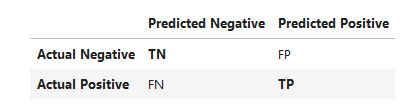


FP is Type I error, FN is Type II error



In [45]:
confusion_matrix = confusion_matrix(y_test, pred_test)
confusion_matrix

array([[40048,   508],
       [  502, 29681]])

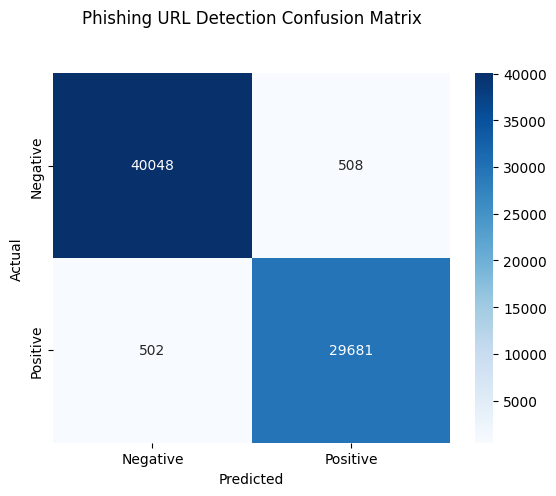

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
ax = sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt = '')

ax.set_title('Phishing URL Detection Confusion Matrix\n\n');
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['Negative','Positive'])
ax.yaxis.set_ticklabels(['Negative','Positive'])

## Display the visualization of the Confusion Matrix.
plt.show()

# Save the figure as a PNG image
fig.savefig('ConfusionMatrix.png')

# You can download the image directly within Colab using the following command if needed
from google.colab import files
files.download('ConfusionMatrix.png')

Testing model prediction with new inputs to prepare for web app:

In [48]:
inputs = [[1, 1, 0, 71, 0]]

pred_inputs = model3.predict(inputs)
pred_inputs[0]

0


Next steps: Use pickle file to transfer model to web app python code

In [49]:
# pickle_out = open("Phishing_URL_Prediction.pkl", mode = "wb")
# pickle.dump(model, pickle_out)
# pickle_out.close()